In [6]:
# ============================================
# 0. Imports & data loading
#    (Keep this consistent with the code used above)
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score

# 1) Load Train / Test data (XGB-wrapper feature space, 84 features)
X_train = pd.read_csv("../data/X_train_xgbsel.csv")
X_test  = pd.read_csv("../data/X_test_xgbsel.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

y_tr = y_train.to_numpy().ravel()
y_te = y_test.to_numpy().ravel()

# ============================================
# 1. Select top-20 features from XGBoost feature importance
# ============================================
fi = pd.read_csv("../data/xgb_feature_importance.csv")

# Sort by importance in descending order and take top 20
fi_top20 = fi.sort_values("importance", ascending=False).head(20)

top20_features = fi_top20["feature"].tolist()
top20_importances = fi_top20["importance"].tolist()

print("\n[INFO] Top-20 features by XGB importance:")
for f, imp in zip(top20_features, top20_importances):
    print(f"  {f:45s} importance = {imp:.4f}")

# Convert feature names to column indices based on X_train column order
top20_idx = [X_train.columns.get_loc(f) for f in top20_features]
top20_idx = np.array(top20_idx, dtype=int)

print("\n[INFO] Index of top-20 features:", top20_idx)
print("[INFO] d =", len(top20_idx))

# ============================================
# 2. RF tuning setup (identical to the GA-RF code)
# ============================================
PARAM_DIST = {
    "n_estimators": randint(100, 650),
    "max_depth": [None, 8, 12],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 8),
    "bootstrap": [True],
    "max_samples": [None, 0.6, 0.8, 1.0],
    "class_weight": [None, "balanced"],
    "criterion": ["gini", "entropy"],
}

STAGE1_N_ITER = globals().get("STAGE1_N_ITER", 80)  # Use the same global setting if defined
RANDOM_STATE  = 42

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=2042)

def tune_rf_for_features(feature_idx, label):
    """
    Given a feature subset (column indices), run RandomizedSearchCV
    for RF tuning with the same settings as in the GA-RF pipeline.
    """
    X_sub = X_train.iloc[:, feature_idx].to_numpy()

    rs = RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=2042, n_jobs=-1),
        param_distributions=PARAM_DIST,
        n_iter=STAGE1_N_ITER,
        scoring="roc_auc",
        cv=cv5,
        n_jobs=-1,
        random_state=2042,
        verbose=0
    )
    rs.fit(X_sub, y_tr)

    best_params = dict(rs.best_params_)
    # Clean up keys that are not needed when creating the final RF
    best_params.pop("random_state", None)
    best_params.pop("n_jobs", None)
    if best_params.get("bootstrap") is False:
        best_params.pop("max_samples", None)

    print(f"\n[CV] {label} best AUC = {rs.best_score_:.4f}")
    print(f"[CV] {label} best params = {best_params}")
    return best_params, float(rs.best_score_)

# ============================================
# 3. RF tuning using only the XGB top-20 features
# ============================================
label = "RF (XGB top-20 features)"
best_params, cv_auc_best = tune_rf_for_features(top20_idx, label)

# ============================================
# 4. Refit on full TRAIN and report TRAIN / TEST AUC
# ============================================
Xtr_sub = X_train.iloc[:, top20_idx].to_numpy()
Xte_sub = X_test.iloc[:,  top20_idx].to_numpy()

rf_final = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_params
)
rf_final.fit(Xtr_sub, y_tr)

# Train / Test predicted probabilities
prob_tr = rf_final.predict_proba(Xtr_sub)[:, 1]
prob_te = rf_final.predict_proba(Xte_sub)[:, 1]

auc_tr = roc_auc_score(y_tr, prob_tr)
auc_te = roc_auc_score(y_te, prob_te)

print("\n========== FINAL RESULTS: RF using XGB top-20 ==========")
print(f"[FINAL] {label}: CV best AUC (from tuning) = {cv_auc_best:.4f}")
print(f"[FINAL] {label}: TRAIN AUC = {auc_tr:.4f}")
print(f"[FINAL] {label}: TEST  AUC = {auc_te:.4f}")
print("========================================================")


X_train: (82, 84)
X_test : (36, 84)
y_train: (82,)
y_test : (36,)

[INFO] Top-20 features by XGB importance:
  VOLUME_NET_OVER_WT                            importance = 0.0659
  TEXTURE_GLRLM_ED_T1Gd_LGRE                    importance = 0.0612
  TEXTURE_GLSZM_NET_FLAIR_LZHGE                 importance = 0.0594
  SOLIDITY_ED                                   importance = 0.0381
  TEXTURE_GLCM_NET_T2_Contrast                  importance = 0.0347
  HISTO_ET_FLAIR_Bin5                           importance = 0.0333
  TEXTURE_GLRLM_ED_T2_GLN                       importance = 0.0331
  HISTO_ET_T1_Bin9                              importance = 0.0308
  TEXTURE_GLCM_ET_FLAIR_Energy                  importance = 0.0297
  HISTO_ED_T1Gd_Bin7                            importance = 0.0285
  HISTO_NET_T1_Bin1                             importance = 0.0283
  TEXTURE_GLSZM_ED_T2_LGZE                      importance = 0.0246
  HISTO_ET_T1_Bin5                              importance = 0.0246
  TEXTU

[INFO] Xtr_top20 shape: (82, 20)
[INFO] Using rf_final (already trained) as the RF model for SHAP.
[INFO] shap_exp_top20.values shape: (82, 20, 2)
[INFO] shap_exp_top20.data   shape: (82, 20)


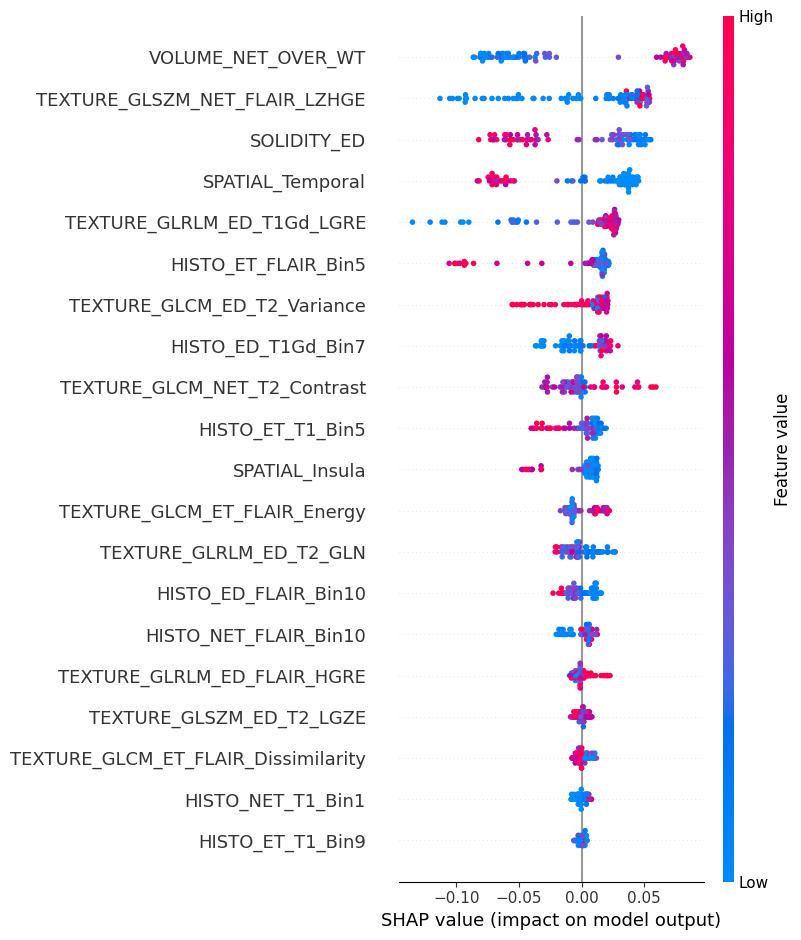

In [7]:
# Cell: RF (XGB top-20) SHAP (clean version, consistent with GA-RF block)

import shap

# Assumptions:
# - rf_final: final RandomForestClassifier already fitted on Xtr_sub (top-20 features)
# - Xtr_sub: training matrix using the XGB top-20 feature subset
# - top20_features or X_train.columns[top20_idx] corresponds to the columns used in Xtr_sub

# 1) Reconstruct a clean DataFrame view for readability (optional)
#    If you still have top20_idx, you can do:
#       Xtr_top20 = X_train.iloc[:, top20_idx]
#    Otherwise, we just wrap Xtr_sub into a DataFrame with the right column names.
try:
    # If top20_idx and X_train exist, use them to be explicit
    Xtr_top20 = X_train.iloc[:, top20_idx]
    feature_names_top20 = Xtr_top20.columns
except NameError:
    # Fallback: assume Xtr_sub already corresponds to the top-20 features
    # and that top20_features is a list of their names.
    Xtr_top20 = pd.DataFrame(Xtr_sub, columns=top20_features)
    feature_names_top20 = Xtr_top20.columns

y_tr = y_train.to_numpy().ravel()

print("[INFO] Xtr_top20 shape:", Xtr_top20.shape)
print("[INFO] Using rf_final (already trained) as the RF model for SHAP.")

# 2) SHAP explainer (tree-based, same style as GA-RF SHAP cell)
explainer_top20 = shap.Explainer(
    rf_final,
    Xtr_top20,          # background = train features (top-20)
    algorithm="tree",
)

# 3) Compute SHAP values for TRAIN
shap_exp_top20 = explainer_top20(Xtr_top20)

vals = shap_exp_top20.values   # shape: (n_samples, n_features) or (n_samples, n_features, n_outputs)
data = shap_exp_top20.data

print("[INFO] shap_exp_top20.values shape:", vals.shape)
print("[INFO] shap_exp_top20.data   shape:", data.shape)

# 4) For binary RF: if SHAP returns per-output values, pick the positive class (index 1)
if vals.ndim == 3:
    # shape: (n_samples, n_features, n_outputs=2)
    vals = vals[:, :, 1]   # -> (n_samples, n_features)

# 5) Summary plot (global importance of XGB top-20 features)
shap.summary_plot(
    vals,
    data,
    feature_names=feature_names_top20,
    show=True
)
